# Importing & Exporting — getting data in and results out

01 Core Python · **▶ 02 Pandas** · 03 Cleaning · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`02_Pandas_Essentials/06_importing_and_exporting_data.ipynb`

---

### In one paragraph (no jargon)

Every analysis starts by reading a file and ends by writing one. Pandas reads CSV, Excel, plain text, JSON, HTML tables and SQL with the same `pd.read_*` family, and writes them back with `.to_*`. The commands are easy; the marks are in the **arguments** — telling pandas which separator to use, which row holds the headers, which sheet to open, and whether to write the index. Getting `index=False` right is the difference between a clean deliverable and a spreadsheet with a mystery first column.

### After this notebook you can

- Read CSV, Excel and delimited text files, with the right separator and header row
- Handle the awkward cases: no header, extra rows at the top, custom missing-value markers
- Write results back to CSV and Excel, including several sheets in one workbook
- Choose a file format deliberately rather than defaulting to CSV

**Assumed knowledge:** `01_series_and_dataframes.ipynb`

### What's inside

1. Setup
2. Reading a CSV
3. Reading Excel workbooks
4. Reading delimited text
5. Writing files back out
6. ⚡ The arguments that actually matter
7. ⚡ Choosing a file format
8. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import tempfile
# WHY: exercises that SAVE a file write to a temp folder, so running this
#      notebook never scatters new files next to your notes.
EXPORT_DIR = tempfile.mkdtemp(prefix='bda_exports_')
print('Exports from this notebook will go to:', EXPORT_DIR)

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_supermarket():
    """Rebuild a dataset statistically equivalent to supermarket.csv (1,000 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 1000
    frame = pd.DataFrame({
        'Invoice ID': [f"{v}_{i}" for i, v in enumerate(rng.choice(['750-67-8428', '226-31-3081', '631-41-3108', '123-19-1176', '373-73-7910', '699-14-3026'], n))],
        'Branch': rng.choice(['A', 'B', 'C'], n, p=[0.34, 0.332, 0.328]),
        'City': rng.choice(['Yangon', 'Mandalay', 'Naypyitaw'], n, p=[0.34, 0.332, 0.328]),
        'Customer type': rng.choice(['Member', 'Normal'], n, p=[0.501, 0.499]),
        'Gender': rng.choice(['Female', 'Male'], n, p=[0.501, 0.499]),
        'Product line': rng.choice(['Fashion accessories', 'Food and beverages', 'Electronic accessories', 'Sports and travel', 'Home and lifestyle', 'Health and beauty'], n, p=[0.178, 0.174, 0.17, 0.166, 0.16, 0.152]),
        'Unit price': rng.normal(55.67, 26.49, n).clip(10.08, 99.96).round(4),
        'Quantity': rng.choice([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], n, p=[0.112, 0.091, 0.09, 0.109, 0.102, 0.098, 0.102, 0.085, 0.092, 0.119]),
        'Tax 5%': rng.normal(15.38, 11.71, n).clip(0.5085, 49.65).round(4),
        'Total': rng.normal(323, 245.9, n).clip(10.6785, 1042.65).round(4),
        'Date': [f"{v}_{i}" for i, v in enumerate(rng.choice(['2/7/2019', '2/15/2019', '3/2/2019', '1/8/2019', '3/14/2019', '3/5/2019'], n))],
        'Time': [f"{v}_{i}" for i, v in enumerate(rng.choice(['19:48', '14:42', '17:38', '17:36', '19:20', '19:39'], n))],
        'Payment': rng.choice(['Ewallet', 'Cash', 'Credit card'], n, p=[0.345, 0.344, 0.311]),
        'cogs': rng.normal(307.6, 234.2, n).clip(10.17, 993).round(4),
        'gross margin percentage': rng.choice([4.761904762], n, p=[1]),
        'gross income': rng.normal(15.38, 11.71, n).clip(0.5085, 49.65).round(4),
        'Rating': rng.normal(6.973, 1.719, n).clip(4, 10).round(4),
    })
    return frame

def rebuild_iris():
    """Exact copy of iris.txt, embedded so this notebook never needs the file."""
    import io
    csv_text = """sepal length,sepal width,petal length,petal width,Iris plant
5.1,3.5,1.4,0.2,Iris-setosa
4.9,3.0,1.4,0.2,Iris-setosa
4.7,3.2,1.3,0.2,Iris-setosa
4.6,3.1,1.5,0.2,Iris-setosa
5.0,3.6,1.4,0.2,Iris-setosa
5.4,3.9,1.7,0.4,Iris-setosa
4.6,3.4,1.4,0.3,Iris-setosa
5.0,3.4,1.5,0.2,Iris-setosa
4.4,2.9,1.4,0.2,Iris-setosa
4.9,3.1,1.5,0.1,Iris-setosa
5.4,3.7,1.5,0.2,Iris-setosa
4.8,3.4,1.6,0.2,Iris-setosa
4.8,3.0,1.4,0.1,Iris-setosa
4.3,3.0,1.1,0.1,Iris-setosa
5.8,4.0,1.2,0.2,Iris-setosa
5.7,4.4,1.5,0.4,Iris-setosa
5.4,3.9,1.3,0.4,Iris-setosa
5.1,3.5,1.4,0.3,Iris-setosa
5.7,3.8,1.7,0.3,Iris-setosa
5.1,3.8,1.5,0.3,Iris-setosa
5.4,3.4,1.7,0.2,Iris-setosa
5.1,3.7,1.5,0.4,Iris-setosa
4.6,3.6,1.0,0.2,Iris-setosa
5.1,3.3,1.7,0.5,Iris-setosa
4.8,3.4,1.9,0.2,Iris-setosa
5.0,3.0,1.6,0.2,Iris-setosa
5.0,3.4,1.6,0.4,Iris-setosa
5.2,3.5,1.5,0.2,Iris-setosa
5.2,3.4,1.4,0.2,Iris-setosa
4.7,3.2,1.6,0.2,Iris-setosa
4.8,3.1,1.6,0.2,Iris-setosa
5.4,3.4,1.5,0.4,Iris-setosa
5.2,4.1,1.5,0.1,Iris-setosa
5.5,4.2,1.4,0.2,Iris-setosa
4.9,3.1,1.5,0.1,Iris-setosa
5.0,3.2,1.2,0.2,Iris-setosa
5.5,3.5,1.3,0.2,Iris-setosa
4.9,3.1,1.5,0.1,Iris-setosa
4.4,3.0,1.3,0.2,Iris-setosa
5.1,3.4,1.5,0.2,Iris-setosa
5.0,3.5,1.3,0.3,Iris-setosa
4.5,2.3,1.3,0.3,Iris-setosa
4.4,3.2,1.3,0.2,Iris-setosa
5.0,3.5,1.6,0.6,Iris-setosa
5.1,3.8,1.9,0.4,Iris-setosa
4.8,3.0,1.4,0.3,Iris-setosa
5.1,3.8,1.6,0.2,Iris-setosa
4.6,3.2,1.4,0.2,Iris-setosa
5.3,3.7,1.5,0.2,Iris-setosa
5.0,3.3,1.4,0.2,Iris-setosa
7.0,3.2,4.7,1.4,Iris-versicolor
6.4,3.2,4.5,1.5,Iris-versicolor
6.9,3.1,4.9,1.5,Iris-versicolor
5.5,2.3,4.0,1.3,Iris-versicolor
6.5,2.8,4.6,1.5,Iris-versicolor
5.7,2.8,4.5,1.3,Iris-versicolor
6.3,3.3,4.7,1.6,Iris-versicolor
4.9,2.4,3.3,1.0,Iris-versicolor
6.6,2.9,4.6,1.3,Iris-versicolor
5.2,2.7,3.9,1.4,Iris-versicolor
5.0,2.0,3.5,1.0,Iris-versicolor
5.9,3.0,4.2,1.5,Iris-versicolor
6.0,2.2,4.0,1.0,Iris-versicolor
6.1,2.9,4.7,1.4,Iris-versicolor
5.6,2.9,3.6,1.3,Iris-versicolor
6.7,3.1,4.4,1.4,Iris-versicolor
5.6,3.0,4.5,1.5,Iris-versicolor
5.8,2.7,4.1,1.0,Iris-versicolor
6.2,2.2,4.5,1.5,Iris-versicolor
5.6,2.5,3.9,1.1,Iris-versicolor
5.9,3.2,4.8,1.8,Iris-versicolor
6.1,2.8,4.0,1.3,Iris-versicolor
6.3,2.5,4.9,1.5,Iris-versicolor
6.1,2.8,4.7,1.2,Iris-versicolor
6.4,2.9,4.3,1.3,Iris-versicolor
6.6,3.0,4.4,1.4,Iris-versicolor
6.8,2.8,4.8,1.4,Iris-versicolor
6.7,3.0,5.0,1.7,Iris-versicolor
6.0,2.9,4.5,1.5,Iris-versicolor
5.7,2.6,3.5,1.0,Iris-versicolor
5.5,2.4,3.8,1.1,Iris-versicolor
5.5,2.4,3.7,1.0,Iris-versicolor
5.8,2.7,3.9,1.2,Iris-versicolor
6.0,2.7,5.1,1.6,Iris-versicolor
5.4,3.0,4.5,1.5,Iris-versicolor
6.0,3.4,4.5,1.6,Iris-versicolor
6.7,3.1,4.7,1.5,Iris-versicolor
6.3,2.3,4.4,1.3,Iris-versicolor
5.6,3.0,4.1,1.3,Iris-versicolor
5.5,2.5,4.0,1.3,Iris-versicolor
5.5,2.6,4.4,1.2,Iris-versicolor
6.1,3.0,4.6,1.4,Iris-versicolor
5.8,2.6,4.0,1.2,Iris-versicolor
5.0,2.3,3.3,1.0,Iris-versicolor
5.6,2.7,4.2,1.3,Iris-versicolor
5.7,3.0,4.2,1.2,Iris-versicolor
5.7,2.9,4.2,1.3,Iris-versicolor
6.2,2.9,4.3,1.3,Iris-versicolor
5.1,2.5,3.0,1.1,Iris-versicolor
5.7,2.8,4.1,1.3,Iris-versicolor
6.3,3.3,6.0,2.5,Iris-virginica
5.8,2.7,5.1,1.9,Iris-virginica
7.1,3.0,5.9,2.1,Iris-virginica
6.3,2.9,5.6,1.8,Iris-virginica
6.5,3.0,5.8,2.2,Iris-virginica
7.6,3.0,6.6,2.1,Iris-virginica
4.9,2.5,4.5,1.7,Iris-virginica
7.3,2.9,6.3,1.8,Iris-virginica
6.7,2.5,5.8,1.8,Iris-virginica
7.2,3.6,6.1,2.5,Iris-virginica
6.5,3.2,5.1,2.0,Iris-virginica
6.4,2.7,5.3,1.9,Iris-virginica
6.8,3.0,5.5,2.1,Iris-virginica
5.7,2.5,5.0,2.0,Iris-virginica
5.8,2.8,5.1,2.4,Iris-virginica
6.4,3.2,5.3,2.3,Iris-virginica
6.5,3.0,5.5,1.8,Iris-virginica
7.7,3.8,6.7,2.2,Iris-virginica
7.7,2.6,6.9,2.3,Iris-virginica
6.0,2.2,5.0,1.5,Iris-virginica
6.9,3.2,5.7,2.3,Iris-virginica
5.6,2.8,4.9,2.0,Iris-virginica
7.7,2.8,6.7,2.0,Iris-virginica
6.3,2.7,4.9,1.8,Iris-virginica
6.7,3.3,5.7,2.1,Iris-virginica
7.2,3.2,6.0,1.8,Iris-virginica
6.2,2.8,4.8,1.8,Iris-virginica
6.1,3.0,4.9,1.8,Iris-virginica
6.4,2.8,5.6,2.1,Iris-virginica
7.2,3.0,5.8,1.6,Iris-virginica
7.4,2.8,6.1,1.9,Iris-virginica
7.9,3.8,6.4,2.0,Iris-virginica
6.4,2.8,5.6,2.2,Iris-virginica
6.3,2.8,5.1,1.5,Iris-virginica
6.1,2.6,5.6,1.4,Iris-virginica
7.7,3.0,6.1,2.3,Iris-virginica
6.3,3.4,5.6,2.4,Iris-virginica
6.4,3.1,5.5,1.8,Iris-virginica
6.0,3.0,4.8,1.8,Iris-virginica
6.9,3.1,5.4,2.1,Iris-virginica
6.7,3.1,5.6,2.4,Iris-virginica
6.9,3.1,5.1,2.3,Iris-virginica
5.8,2.7,5.1,1.9,Iris-virginica
6.8,3.2,5.9,2.3,Iris-virginica
6.7,3.3,5.7,2.5,Iris-virginica
6.7,3.0,5.2,2.3,Iris-virginica
6.3,2.5,5.0,1.9,Iris-virginica
6.5,3.0,5.2,2.0,Iris-virginica
6.2,3.4,5.4,2.3,Iris-virginica
5.9,3.0,5.1,1.8,Iris-virginica"""
    return pd.read_csv(io.StringIO(csv_text))


def rebuild_olympic_athletes():
    """Rebuild a dataset statistically equivalent to olympic_athletes.xlsx (92 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 92
    frame = pd.DataFrame({
        'col_0': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Sum of Total Medals', 'Row Labels', 'Afghanistan', 'Algeria', 'Argentina', 'Armenia'], n))],
        'col_1': [f"{v}_{i}" for i, v in enumerate(rng.choice(['1', '2', '3', '4', '5', '12'], n))],
        'col_2': rng.normal(107.3, 400.4, n).clip(1, 2002).round().astype(int),
        'col_3': rng.normal(61.79, 274.4, n).clip(1, 2004).round().astype(int),
        'col_4': rng.normal(120.3, 418.3, n).clip(1, 2006).round().astype(int),
        'col_5': rng.normal(58.22, 266.9, n).clip(1, 2008).round().astype(int),
        'col_6': rng.normal(110.2, 402.7, n).clip(1, 2010).round().astype(int),
        'col_7': rng.normal(60.53, 272.3, n).clip(1, 2012).round().astype(int),
        'col_8': [f"{v}_{i}" for i, v in enumerate(rng.choice(['2', '1', '3', '8', '7', '11'], n))],
    })
    frame.loc[rng.choice(n, int(n * 0.0217), replace=False), 'col_0'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.2391), replace=False), 'col_1'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.7283), replace=False), 'col_2'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.2717), replace=False), 'col_3'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.7500), replace=False), 'col_4'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.2065), replace=False), 'col_5'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.7283), replace=False), 'col_6'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.2609), replace=False), 'col_7'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0326), replace=False), 'col_8'] = np.nan
    return frame

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Exports from this notebook will go to: /tmp/bda_exports_0a3x5ujx
Setup complete. pandas 3.0.2 | numpy 2.4.4


# Importing & Exporting Data in Pandas — A Complete Reference

**Datasets:** `supermarket.csv`, `Olympic_Athletes.xlsx`, `iris.txt` — three different file formats, on purpose, so every major `pd.read_*` / `df.to_*` pair gets exercised on real data rather than a toy example.

Before you can clean, transform, or model anything, you have to get it **into** pandas correctly — and get your results **back out** in a format your teammates/tools can use. This sounds trivial until you hit the details: a header row in the wrong place, a delimiter that isn't a comma, a huge file that doesn't fit in memory, or an export that silently drags along a meaningless index column. This notebook works through all of it.

## 1. Reading CSV files — the basics and the details that trip people up

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams['figure.dpi'] = 100

# --- Standard read: first row is treated as the header ---
df = load_data('supermarket.csv', rebuild=rebuild_supermarket, header=0)
print(f"Shape: {df.shape}")
df.head(3)

Loaded 'supermarket.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4


In [3]:
# --- header=None: tells pandas there is NO header row -- every row is data,
#     and columns get default integer names (0, 1, 2, ...) ---
df_no_header = load_data('supermarket.csv', rebuild=rebuild_supermarket, header=None)
print("With header=None, the real header row becomes just another data row:")
df_no_header.head(2)

Loaded 'supermarket.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
With header=None, the real header row becomes just another data row:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
1,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761904762,26.1415,9.1


In [4]:
# --- header=1: skip the first row and use the SECOND row as the header instead ---
# Useful for files with a title/metadata row above the real column headers.
df_header_1 = load_data('supermarket.csv', rebuild=rebuild_supermarket, header=1)
print("With header=1, the true header row (row 0) becomes a discarded label and row 1 becomes the header:")
df_header_1.head(2)

Loaded 'supermarket.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
With header=1, the true header row (row 0) becomes a discarded label and row 1 becomes the header:


,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761904762,26.1415.1,9.1
0,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
1,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4


In [5]:
# --- Renaming unlabeled columns programmatically ---
df_prefixed = load_data('supermarket.csv', rebuild=rebuild_supermarket, header=None).add_prefix("col_")
print("add_prefix() is a quick way to give meaningless integer columns a readable name:")
df_prefixed.head(2)

Loaded 'supermarket.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
add_prefix() is a quick way to give meaningless integer columns a readable name:


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_16
0,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
1,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761904762,26.1415,9.1


In [6]:
# --- skiprows: skip specific row NUMBERS (not header-related) --
# e.g. skip two known-bad rows (indices 1 and 2) while keeping the real header
df_skipped = load_data('supermarket.csv', rebuild=rebuild_supermarket, header=0, skiprows=[1, 2])
print(f"Original rows: {df.shape[0]}, after skipping rows 1 & 2: {df_skipped.shape[0]}")
df_skipped.head(3)

Loaded 'supermarket.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Original rows: 1000, after skipping rows 1 & 2: 998


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
1,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
2,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


### Other CSV-reading options worth knowing
- `usecols=['col_a', 'col_b']` — load only the columns you need (big memory/speed win on wide files)
- `dtype={'col': 'category'}` — force a column's type on load, instead of letting pandas guess (guessing can be slow and sometimes wrong, e.g. IDs read as float)
- `na_values=['NA', '?', 'unknown']` — tell pandas which literal strings should be treated as missing
- `nrows=1000` — read only the first N rows (fast sanity-check on a huge file before loading it all)
- `chunksize=10000` — returns an iterator of DataFrames instead of one giant DataFrame, so files far bigger than RAM can still be processed piece by piece

In [7]:
# `chunksize` demo: process a file in pieces rather than all at once.
# (Our file is small, so this is for illustration -- the real payoff shows up on multi-GB files.)
chunk_totals = []
for chunk in load_data('supermarket.csv', rebuild=rebuild_supermarket, header=0, chunksize=5):
    chunk_totals.append(len(chunk))
print(f"Processed the file in {len(chunk_totals)} chunks of up to 5 rows each: {chunk_totals}")

# `usecols` demo: only load the columns we actually need
df_slim = load_data('supermarket.csv', rebuild=rebuild_supermarket, header=0, usecols=['Invoice ID', 'Branch', 'Total'])
print(f"\nFull read: {df.shape[1]} columns.  usecols read: {df_slim.shape[1]} columns -- faster & lighter.")
df_slim.head(3)

Loaded 'supermarket.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


Processed the file in 200 chunks of up to 5 rows each: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
Loaded 'supermarket.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets

Full read: 17 columns.  usecols read: 3 columns -- faster & lighter.


,Invoice ID,Branch,Total
0,750-67-8428,A,548.9715
1,226-31-3081,C,80.2200
2,631-41-3108,A,340.5255


## 2. Reading Excel files (`.xlsx`)

In [8]:
df_excel = load_data('olympic_athletes.xlsx', rebuild=rebuild_olympic_athletes, header=0)
print(f"Shape: {df_excel.shape}")
df_excel.head(3)

Loaded 'olympic_athletes.xlsx' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


Shape: (91, 9)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sum of Total Medals,Column Labels,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Row Labels,2000,2002.0,2004.0,2006.0,2008.0,2010.0,2012.0,Grand Total


In [9]:
# Excel files can have MULTIPLE SHEETS -- list them, and load a specific one by name or index
sheet_names = pd.ExcelFile(dataset_path('olympic_athletes.xlsx', rebuild=rebuild_olympic_athletes)).sheet_names
print(f"Sheets available in this workbook: {sheet_names}")

# sheet_name=0 (default) loads the first sheet; sheet_name='SheetName' loads by name;
# sheet_name=None loads EVERY sheet at once, returned as a dict of {sheet_name: DataFrame}
all_sheets = load_data('olympic_athletes.xlsx', rebuild=rebuild_olympic_athletes, sheet_name=None)
print(f"Loaded {len(all_sheets)} sheet(s) as a dict: {list(all_sheets.keys())}")

Sheets available in this workbook: ['Sheet1', 'Sheet5', 'Sheet2', 'Sheet3', 'Sheet4', 'OlympicAthletes']
Loaded 'olympic_athletes.xlsx' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


Loaded 6 sheet(s) as a dict: ['Sheet1', 'Sheet5', 'Sheet2', 'Sheet3', 'Sheet4', 'OlympicAthletes']


## 3. Reading delimited text files (`.txt`)

In [10]:
# read_table() is essentially read_csv() with a different DEFAULT delimiter (tab, not comma)
df_text_default = load_data('iris.txt', rebuild=rebuild_iris)
print("Default read_table() (expects tab-separated values) on a file that's ACTUALLY comma-separated:")
print(f"  -> parsed into {df_text_default.shape[1]} column(s) -- a strong sign the delimiter guess was wrong!")
df_text_default.head(2)

Loaded 'iris.txt' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Default read_table() (expects tab-separated values) on a file that's ACTUALLY comma-separated:
  -> parsed into 5 column(s) -- a strong sign the delimiter guess was wrong!


,sepal length,sepal width,petal length,petal width,Iris plant
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa


In [11]:
# Explicitly telling pandas the real separator fixes it immediately
df_text_fixed = load_data('iris.txt', rebuild=rebuild_iris, sep=',')
print(f"With sep=',' specified explicitly -> {df_text_fixed.shape[1]} columns (correct!)")
df_text_fixed.head(3)

Loaded 'iris.txt' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
With sep=',' specified explicitly -> 5 columns (correct!)


,sepal length,sepal width,petal length,petal width,Iris plant
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


**Lesson from Sections 1 & 3 combined:** never assume a file's structure — a wrong `header` row or a wrong `sep` silently produces a DataFrame that *looks* like it worked (no error!) but is structurally wrong. Always `.head()` and check `.shape`/`.dtypes` immediately after reading any new file.

## 4. A quick visual sanity-check after import
Once the data is in, a fast plot is often the best way to confirm it loaded correctly and looks the way you expect.

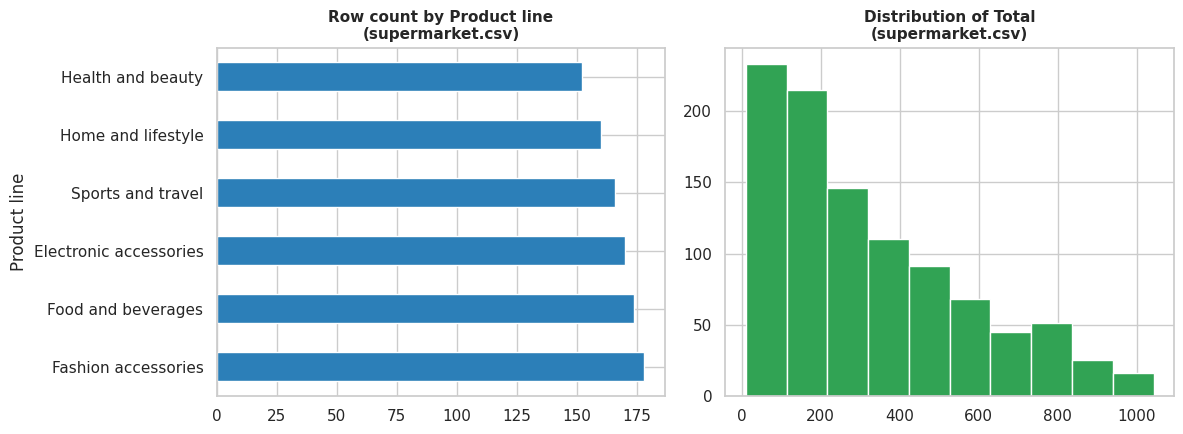

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df['Product line'].value_counts().plot(kind='barh', ax=axes[0], color='#2c7fb8')
axes[0].set_title('Row count by Product line\n(supermarket.csv)', fontweight='bold', fontsize=11)

axes[1].hist(df['Total'], bins=10, color='#31a354', edgecolor='white')
axes[1].set_title('Distribution of Total\n(supermarket.csv)', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Exporting data back out
Exporting is just as easy to get subtly wrong as importing — the single most common mistake is forgetting `index=False` and ending up with a meaningless extra column of row numbers in your output file.

In [13]:
# --- Export to CSV ---
df_skipped.to_csv(os.path.join(EXPORT_DIR, 'export.csv'), index=False, header=True)
print("Wrote export.csv")

# What happens if you forget index=False? An unwanted 'Unnamed: 0' column appears on re-import.
df_skipped.to_csv(os.path.join(EXPORT_DIR, 'export_with_index.csv'), index=True)
reread = pd.read_csv(os.path.join(EXPORT_DIR, 'export_with_index.csv'))
print(f"\nForgetting index=False adds a stray column: {reread.columns.tolist()[:2]} ...")
print("(That first column is just the old row number, re-imported as if it were real data -- avoid this!)")

Wrote export.csv

Forgetting index=False adds a stray column: ['Unnamed: 0', 'Invoice ID'] ...
(That first column is just the old row number, re-imported as if it were real data -- avoid this!)


In [14]:
# --- Export to Excel ---
df_skipped.to_excel(os.path.join(EXPORT_DIR, 'export1.xlsx'), index=False, header=True)
print("Wrote export1.xlsx")

# --- Export to JSON (great for APIs / web services) ---
df_skipped.head(5).to_json(os.path.join(EXPORT_DIR, 'export.json'), orient='records', indent=2)
print("Wrote export.json (orient='records' -> a list of {column: value} dicts, the most web-friendly shape)")

# --- Export to Parquet (columnar, compressed, MUCH faster to read/write for big data than CSV) ---
try:
    df_skipped.to_parquet(os.path.join(EXPORT_DIR, 'export.parquet'), index=False)
    print("Wrote export.parquet")
except ImportError:
    print("Parquet export needs the 'pyarrow' or 'fastparquet' package installed -- skipped here.")

Wrote export1.xlsx
Wrote export.json (orient='records' -> a list of {column: value} dicts, the most web-friendly shape)
Parquet export needs the 'pyarrow' or 'fastparquet' package installed -- skipped here.


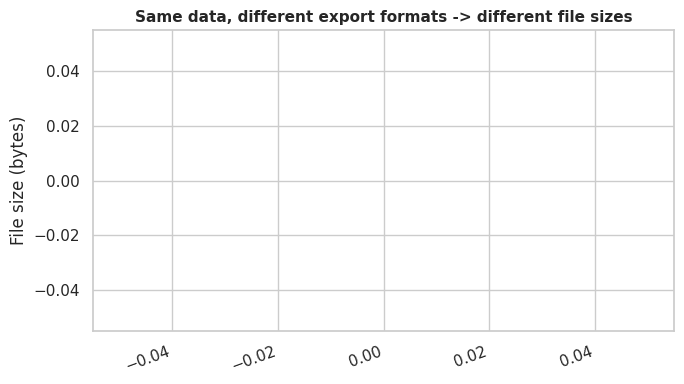

In [15]:
import os
sizes = {}
for fname in ["export.csv", "export1.xlsx", "export.json"]:
    if os.path.exists(fname):
        sizes[fname] = os.path.getsize(fname)
if os.path.exists("export.parquet"):
    sizes["export.parquet"] = os.path.getsize("export.parquet")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sizes.keys(), sizes.values(), color=sns.color_palette('mako', len(sizes)))
ax.set_ylabel('File size (bytes)')
ax.set_title('Same data, different export formats -> different file sizes', fontweight='bold', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Key takeaways

| Format | Read function | Write function | Best for |
|---|---|---|---|
| CSV | `pd.read_csv()` | `df.to_csv(index=False)` | Universal, human-readable, git-diffable |
| Excel | `pd.read_excel()` | `df.to_excel(index=False)` | Business stakeholders, multi-sheet workbooks |
| Delimited text | `pd.read_table()` / `read_csv(sep=...)` | `df.to_csv(sep=...)` | Legacy/scientific data, custom delimiters |
| JSON | `pd.read_json()` | `df.to_json(orient='records')` | APIs, web services, nested data |
| Parquet | `pd.read_parquet()` | `df.to_parquet(index=False)` | Big data — compressed, columnar, fast |

**The three habits that prevent almost every import bug:**
1. Check `header=` matches where your real column names actually are.
2. Check `sep=`/delimiter matches the file, don't trust the default.
3. Always pass `index=False` on export unless you deliberately want the row index saved.

### ⚡ Beyond the syllabus — the `read_csv` arguments that actually matter

`pd.read_csv('file.csv')` handles the easy case. Real files have semicolons instead of commas, three rows of company letterhead above the headers, `'N/A'` and `'-'` scattered where numbers should be, and dates stored as text. Each is one argument. Knowing these six turns a broken import into a clean one — and a broken import loses every subsequent mark.

In [16]:
import io

# A deliberately awkward file — this is what real data looks like
messy = """Quarterly Export - Confidential
Generated 2026-07-01

Order ID;Order Date;Customer;Amount;Status
1001;2026-01-15;Ravi Kumar;1200,50;Shipped
1002;2026-01-18;Meera Nair;N/A;Pending
1003;2026-02-02;John Das;-;Cancelled
1004;2026-02-14;Ali Khan;2100,75;Shipped"""

print("=== The naive read — pandas cannot make sense of it ===")
try:
    display(pd.read_csv(io.StringIO(messy)).head(3))
except Exception as e:
    print(f"  {type(e).__name__}: {e}")
    print("  ^ THIS is the error you'll see when the separator or header row is wrong.")
    print("    It is not a broken file — it's a missing argument.")

print("\n=== The correct read — six arguments do all the work ===")
clean = pd.read_csv(
    io.StringIO(messy),
    sep=';',                    # this file is semicolon-separated, not comma
    skiprows=3,                 # ignore the letterhead above the real header row
    na_values=['N/A', '-', ''], # treat these markers as missing, not as text
    decimal=',',                # European format: 1200,50 means 1200.50
    parse_dates=['Order Date'], # read as real dates, so .dt and sorting work
    dtype={'Order ID': str},    # keep IDs as text — leading zeros survive
)
display(clean)
print("\nColumn types after the correct read:")
print(clean.dtypes.to_string())
print("\nBecause Order Date is a real date, this now works:")
print("  earliest:", clean['Order Date'].min().date(), " latest:", clean['Order Date'].max().date())
print("  month   :", clean['Order Date'].dt.month_name().tolist())

=== The naive read — pandas cannot make sense of it ===
  ParserError: Error tokenizing data. C error: Expected 1 fields in line 5, saw 2

  ^ THIS is the error you'll see when the separator or header row is wrong.
    It is not a broken file — it's a missing argument.

=== The correct read — six arguments do all the work ===


,Order ID,Order Date,Customer,Amount,Status
0,1001,2026-01-15,Ravi Kumar,1200.50,Shipped
1,1002,2026-01-18,Meera Nair,NaN,Pending
2,1003,2026-02-02,John Das,NaN,Cancelled
3,1004,2026-02-14,Ali Khan,2100.75,Shipped



Column types after the correct read:
Order ID                 str
Order Date    datetime64[us]
Customer                 str
Amount               float64
Status                   str

Because Order Date is a real date, this now works:
  earliest: 2026-01-15  latest: 2026-02-14
  month   : ['January', 'January', 'February', 'February']


In [17]:
# Reading a huge file without running out of memory
supermarket = load_data('supermarket.csv', rebuild=rebuild_supermarket)

# usecols= — read only the columns you need
subset = pd.read_csv(io.StringIO(supermarket.to_csv(index=False)),
                     usecols=['Branch', 'City', 'Total', 'Rating'])
print("Only 4 of", supermarket.shape[1], "columns read:", list(subset.columns))

# nrows= — peek at the top of a big file before committing to it
peek = pd.read_csv(io.StringIO(supermarket.to_csv(index=False)), nrows=5)
print("\nFirst 5 rows only — useful for checking the shape of an unknown file:")
display(peek[['Invoice ID', 'Branch', 'Total']])

# chunksize= — process a file bigger than memory, one block at a time
total = 0
for chunk in pd.read_csv(io.StringIO(supermarket.to_csv(index=False)), chunksize=200):
    total += chunk['Total'].sum()          # aggregate each block, keep only the running number
print(f"\nTotal computed in 200-row chunks: {total:,.2f}")
print(f"Same as reading it all at once   : {supermarket['Total'].sum():,.2f}")

Loaded 'supermarket.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


Only 4 of 17 columns read: ['Branch', 'City', 'Total', 'Rating']

First 5 rows only — useful for checking the shape of an unknown file:


,Invoice ID,Branch,Total
0,750-67-8428,A,548.9715
1,226-31-3081,C,80.2200
2,631-41-3108,A,340.5255
3,123-19-1176,A,489.0480
4,373-73-7910,A,634.3785



Total computed in 200-row chunks: 322,966.75
Same as reading it all at once   : 322,966.75


### ⚡ Beyond the syllabus — choosing a file format deliberately

CSV is the default because everyone can open it, not because it's good. It stores no data types (dates come back as text every time), it's slow, and it's large. Knowing when to use Parquet or Excel instead — and being able to say why — is a small thing that reads as professional.

In [18]:
demo = supermarket.head(200).copy()
demo['Date'] = pd.to_datetime(demo['Date'], format='mixed', errors='coerce')

paths = {}
paths['csv']  = os.path.join(EXPORT_DIR, 'demo.csv');   demo.to_csv(paths['csv'], index=False)
paths['xlsx'] = os.path.join(EXPORT_DIR, 'demo.xlsx');  demo.to_excel(paths['xlsx'], index=False)
try:
    paths['parquet'] = os.path.join(EXPORT_DIR, 'demo.parquet'); demo.to_parquet(paths['parquet'])
except Exception as e:
    paths.pop('parquet', None)
    print("(parquet needs pyarrow — not installed here, so it's skipped)\n")

print(f"{'FORMAT':<10}{'SIZE':>10}   DATE COLUMN SURVIVES?")
print("-" * 48)
for kind, path in paths.items():
    size = os.path.getsize(path)
    reader = {'csv': pd.read_csv, 'xlsx': pd.read_excel, 'parquet': pd.read_parquet}[kind]
    back = reader(path)
    keeps = pd.api.types.is_datetime64_any_dtype(back['Date'])
    print(f"{kind:<10}{size:>9,}B   {'yes' if keeps else 'NO — comes back as text'}")

print("""
WHEN TO USE WHICH
  CSV      sharing with anyone, any tool. Loses all type information.
  Excel    when a human will open it. Supports several sheets and formatting.
  Parquet  large data, repeated analysis. Small, fast, and keeps every dtype.
  JSON     nested/API data. Verbose but preserves structure.""")

(parquet needs pyarrow — not installed here, so it's skipped)

FORMAT          SIZE   DATE COLUMN SURVIVES?
------------------------------------------------
csv          26,562B   NO — comes back as text


xlsx         24,465B   yes

WHEN TO USE WHICH
  CSV      sharing with anyone, any tool. Loses all type information.
  Excel    when a human will open it. Supports several sheets and formatting.
  Parquet  large data, repeated analysis. Small, fast, and keeps every dtype.
  JSON     nested/API data. Verbose but preserves structure.


In [19]:
# Writing several sheets into one workbook — the deliverable a manager wants
report_path = os.path.join(EXPORT_DIR, 'sales_report.xlsx')

with pd.ExcelWriter(report_path, engine='openpyxl') as writer:
    demo.head(50).to_excel(writer, sheet_name='Raw Data', index=False)
    (demo.groupby('Branch')['Total'].agg(['count', 'sum', 'mean']).round(2)
         .to_excel(writer, sheet_name='By Branch'))
    (demo.groupby('Product line')['Total'].sum().sort_values(ascending=False)
         .to_frame('revenue').to_excel(writer, sheet_name='By Product'))

print("Written:", os.path.basename(report_path))
print("Sheets  :", pd.ExcelFile(report_path).sheet_names)
print("\nReading one sheet back:")
display(pd.read_excel(report_path, sheet_name='By Branch').head())

print("\n🔧 index=False is the argument to remember. Without it every export gains a")
print("   nameless first column of row numbers — which then reappears as 'Unnamed: 0'")
print("   the next time anyone reads the file. Fix it at the source, not afterwards.")

Written: sales_report.xlsx


Sheets  : ['Raw Data', 'By Branch', 'By Product']

Reading one sheet back:


,Branch,count,sum,mean
0,A,66,24376.20,369.34
1,B,60,21333.80,355.56
2,C,74,29438.49,397.82



🔧 index=False is the argument to remember. Without it every export gains a
   nameless first column of row numbers — which then reappears as 'Unnamed: 0'
   the next time anyone reads the file. Fix it at the source, not afterwards.


---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Read a CSV | `pd.read_csv('file.csv')` |
| Different separator | `sep=';'` or `sep='\t'` |
| Skip junk rows at the top | `skiprows=3` |
| No header row in the file | `header=None, names=[…]` |
| Custom missing markers | `na_values=['N/A', '-']` |
| Read dates as dates | `parse_dates=['Order Date']` |
| Keep IDs as text | `dtype={'id': str}` |
| Only some columns | `usecols=['a', 'b']` |
| Only the first N rows | `nrows=100` |
| Huge file, in blocks | `chunksize=10000` |
| Read Excel | `pd.read_excel('f.xlsx', sheet_name='Sheet1')` |
| List the sheets | `pd.ExcelFile('f.xlsx').sheet_names` |
| Read a text file | `pd.read_csv('f.txt', sep='\t')` |
| Write a CSV | `df.to_csv('out.csv', index=False)` |
| Write Excel | `df.to_excel('out.xlsx', index=False)` |
| Several sheets | `with pd.ExcelWriter(p) as w: df.to_excel(w, sheet_name=…)` |

### Adapting this in the exam

- Given a `.txt` file? It's still `read_csv` — just set `sep=` to whatever separates the values.
- Told the file has no header? `header=None, names=['a','b','c']`.
- Asked to export 'without the index'? That's `index=False` — the mark is for remembering it.
- Asked for several tables in one file? `pd.ExcelWriter` with a `sheet_name` per table.

### Traps that cost marks

- Forgetting `index=False` on export adds a stray row-number column that comes back as `Unnamed: 0`.
- `sheetname=` was renamed to `sheet_name=` years ago. Old notebooks still using it will error.
- `FileNotFoundError` almost always means the working directory isn't what you think. Check `os.getcwd()` and use a relative path from there.
- Dates read from CSV arrive as **text**. Without `parse_dates=`, sorting is alphabetical and `.dt` fails.
- IDs with leading zeros (`'007'`) become `7` unless you pass `dtype={'id': str}`.
- `pd.read_excel` needs `openpyxl` installed for `.xlsx` files. If it errors, that's usually why.